In [1]:
#xgboost----> xgboost library connect with xgboostclassifier 

In [7]:
import pandas as pd 

df=pd.DataFrame({'Followers':[1000,1500,2000,2500,3000,3500,4000,4500,5000,5500,6000,7000,8000,9000,10000],
                 'Likes':[80,120,150,200,250,300,350,420,500,600,700,800,950,1100,1250],
                 'Comments':[5,8,10,15,18,20,25,30,35,40,45,50,60,65,70],
                 'Shares':[2,4,5,8,10,12,15,20,25,30,35,40,50,60,75],
                 'Watch_Time':[15,20,25,30,35,40,45,50,55,60,65,70,75,80,85] , 
                 'Saves':[1,2,3,5,6,8,10,12,15,18,20,25,30,35,40] , 
                 'Viral' : [0,0,0,0,0,0,0,1,1,1,1,1,1,1,1]
                })

In [8]:
df

,Followers,Likes,Comments,Shares,Watch_Time,Saves,Viral
0,1000,80,5,2,15,1,0
1,1500,120,8,4,20,2,0
2,2000,150,10,5,25,3,0
3,2500,200,15,8,30,5,0
4,3000,250,18,10,35,6,0
5,3500,300,20,12,40,8,0
6,4000,350,25,15,45,10,0
7,4500,420,30,20,50,12,1
8,5000,500,35,25,55,15,1
9,5500,600,40,30,60,18,1


Text(0.5, 1.0, 'Followers vs Likes')

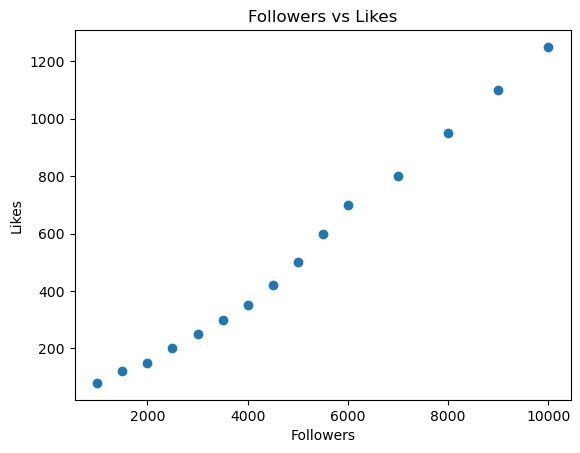

In [9]:
import matplotlib.pyplot as plt 

plt.scatter(df["Followers"] , df["Likes"])
plt.xlabel("Followers")
plt.ylabel("Likes")
plt.title("Followers vs Likes")


Text(0.5, 1.0, 'Viral vs Shares')

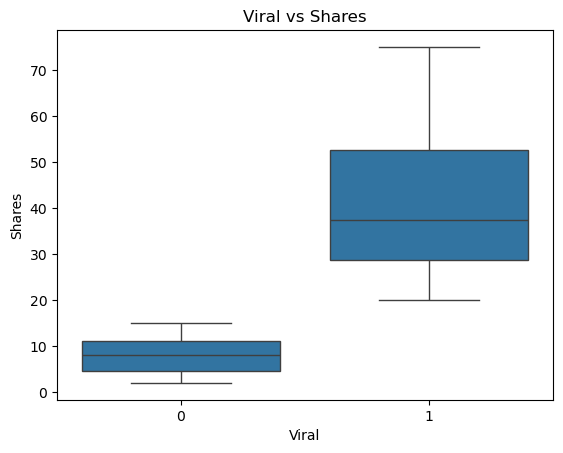

In [10]:
import seaborn as sns
sns.boxplot(x='Viral' , y = 'Shares' , data = df)
plt.title("Viral vs Shares")


In [11]:
df.columns

Index(['Followers', 'Likes', 'Comments', 'Shares', 'Watch_Time', 'Saves',
       'Viral'],
      dtype='object')

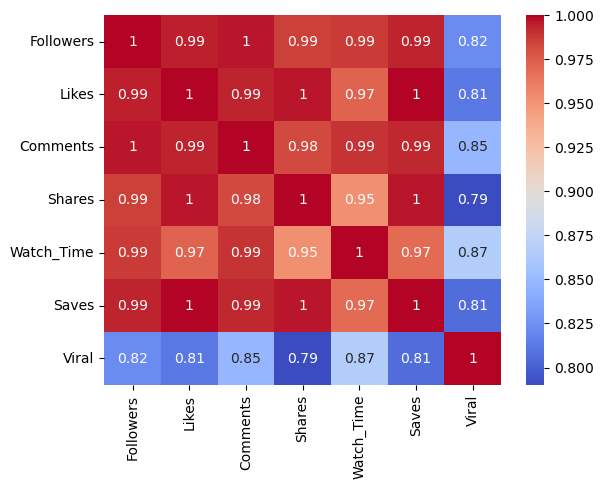

In [12]:
sns.heatmap(df.corr(),annot = True , cmap = "coolwarm")
plt.show()

In [13]:
x = df[['Followers', 'Likes', 'Comments', 'Shares', 'Watch_Time', 'Saves']]
y = df['Viral']

print(x)

print(y)

    Followers  Likes  Comments  Shares  Watch_Time  Saves
0        1000     80         5       2          15      1
1        1500    120         8       4          20      2
2        2000    150        10       5          25      3
3        2500    200        15       8          30      5
4        3000    250        18      10          35      6
5        3500    300        20      12          40      8
6        4000    350        25      15          45     10
7        4500    420        30      20          50     12
8        5000    500        35      25          55     15
9        5500    600        40      30          60     18
10       6000    700        45      35          65     20
11       7000    800        50      40          70     25
12       8000    950        60      50          75     30
13       9000   1100        65      60          80     35
14      10000   1250        70      75          85     40
0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     1
8     1


In [14]:
from sklearn.model_selection import train_test_split

x_train , x_test , y_train , y_test = train_test_split(x,y,test_size =0.2, random_state = 42)

#Train_Data
print(x_train)
print()
print(y_train)

    Followers  Likes  Comments  Shares  Watch_Time  Saves
13       9000   1100        65      60          80     35
5        3500    300        20      12          40      8
8        5000    500        35      25          55     15
2        2000    150        10       5          25      3
1        1500    120         8       4          20      2
14      10000   1250        70      75          85     40
4        3000    250        18      10          35      6
7        4500    420        30      20          50     12
10       6000    700        45      35          65     20
12       8000    950        60      50          75     30
3        2500    200        15       8          30      5
6        4000    350        25      15          45     10

13    1
5     0
8     1
2     0
1     0
14    1
4     0
7     1
10    1
12    1
3     0
6     0
Name: Viral, dtype: int64


In [15]:
print(x_test)

    Followers  Likes  Comments  Shares  Watch_Time  Saves
9        5500    600        40      30          60     18
11       7000    800        50      40          70     25
0        1000     80         5       2          15      1


In [16]:
print(y_test)

9     1
11    1
0     0
Name: Viral, dtype: int64


In [3]:
%pip install xgboost

  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/48.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/48.9 MB 1.1 MB/s eta 0:00:44
    --------------------------------------- 0.8/48.9 MB 1.2 MB/s eta 0:00:39
    --------------------------------------- 0.8/48.9 MB 1.2 MB/s eta 0:00:39
    --------------------------------------- 1.0/48.9 MB 1.2 MB/s eta 0:00:42
   - -------------------------------------- 1.3/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.3/48.9 MB 1.0 MB/s eta 0:00:47
   - -------------------------------------- 1.8/48.9 MB 1.1 MB/s eta 0:00:43
   - -------------------------------------- 2.4/48.9 MB 1.3 MB/s eta 0:00:38
   -- ------------------------------------- 2.9/48.9 MB 1.4 MB/s eta 0:00:33
   -- ---------------------

In [17]:
from xgboost import XGBClassifier

In [134]:
model = XGBClassifier(n_estimators=100 , learning_rate = 0.1 , random_state = 42 , max_depth = 3 ,
                     subsample = 0.8 , colsample_bytree = 0.8 ,eval_metric = "logloss" )

In [135]:
model.fit(x_train , y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [136]:
Prediction= model.predict(x_test)
print("Actual_Data")
print(y_test.values)
print()
print("Prediction_Data")
print(Prediction)

Actual_Data
[1 1 0]

Prediction_Data
[1 1 0]


In [137]:
prob = model.predict_proba(x_test)
print(prob)

[[0.2239818  0.7760182 ]
 [0.19899112 0.8010089 ]
 [0.80912256 0.19087741]]


In [138]:
new_data = pd.DataFrame({'Followers':[900], 'Likes':[250], 'Comments':[50], 'Shares':[6], 'Watch_Time':[59], 'Saves':[20],})
print(new_pred)

[1]


In [139]:
new_pred = model.predict(new_data)
print(new_pred[0])


0


In [140]:
new_data1 = pd.DataFrame({'Followers':[19000], 'Likes':[200], 'Comments':[100], 'Shares':[100], 'Watch_Time':[50], 'Saves':[50],})
new_pred = model.predict(new_data1)
print(new_pred[0])


1


In [141]:
from sklearn.metrics import (accuracy_score , confusion_matrix , classification_report)

In [142]:
ac_score = accuracy_score(y_test,Prediction)
print("Accuracy_score")
print(ac_score)

Accuracy_score
1.0


In [143]:
C_matrix = confusion_matrix(y_test , Prediction)
print("Confusion_Matirx")
print(C_matrix)

Confusion_Matirx
[[1 0]
 [0 2]]


In [144]:
C_Report = classification_report(y_test ,Prediction)
print("Classification_Report")
print(C_Report)

Classification_Report
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         1
           1       1.00      1.00      1.00         2

    accuracy                           1.00         3
   macro avg       1.00      1.00      1.00         3
weighted avg       1.00      1.00      1.00         3



In [145]:
df1 = pd.read_excel(r"data\book1.xlsx")

In [146]:
df1

,Age,Previous_Orders,Pages_Viewed,Time_Spent,Cart_Items,Discount,Purchased,Unnamed: 7,Unnamed: 8
0,21,1,3,5,0,0,0,NaN,NaN
1,25,2,5,8,1,5,0,NaN,NaN
2,28,3,6,10,1,0,0,NaN,NaN
3,32,4,8,15,2,10,0,NaN,NaN
4,35,5,10,18,2,5,0,NaN,NaN
5,29,2,12,20,3,15,1,NaN,NaN
6,40,6,14,25,3,10,1,NaN,NaN
7,45,8,16,30,4,20,1,NaN,NaN
8,31,5,18,35,4,15,1,NaN,NaN
9,38,7,20,40,5,25,1,NaN,NaN


In [147]:
df.columns


Index(['Age', 'Previous_Orders', 'Pages_Viewed', 'Time_Spent', 'Cart_Items',
       'Discount', 'Purchased', 'Unnamed: 7', 'Unnamed: 8'],
      dtype='object')

In [148]:
x1 = df[['Age', 'Previous_Orders', 'Pages_Viewed', 'Time_Spent', 'Cart_Items',
       'Discount']]
y1 = df['Purchased']

print(x1)

print(y1)

    Age  Previous_Orders  Pages_Viewed  Time_Spent  Cart_Items  Discount
0    21                1             3           5           0         0
1    25                2             5           8           1         5
2    28                3             6          10           1         0
3    32                4             8          15           2        10
4    35                5            10          18           2         5
5    29                2            12          20           3        15
6    40                6            14          25           3        10
7    45                8            16          30           4        20
8    31                5            18          35           4        15
9    38                7            20          40           5        25
10   50               10            22          45           5        20
11   27                3             7          12           1        10
12   33                4            11          22 

In [149]:
from sklearn.model_selection import train_test_split

x1_train , x1_test , y1_train , y1_test = train_test_split(x1,y1,test_size =0.2, random_state = 42)

#Train_Data
print(x1_train)
print()
print(y1_train)

    Age  Previous_Orders  Pages_Viewed  Time_Spent  Cart_Items  Discount
13   42                9            15          28           3         5
5    29                2            12          20           3        15
8    31                5            18          35           4        15
2    28                3             6          10           1         0
1    25                2             5           8           1         5
14   24                1             4           6           0         0
4    35                5            10          18           2         5
7    45                8            16          30           4        20
10   50               10            22          45           5        20
12   33                4            11          22           2        15
3    32                4             8          15           2        10
6    40                6            14          25           3        10

13    1
5     1
8     1
2     0
1     0
14    0
4 

In [150]:
print(x1_test)

    Age  Previous_Orders  Pages_Viewed  Time_Spent  Cart_Items  Discount
9    38                7            20          40           5        25
11   27                3             7          12           1        10
0    21                1             3           5           0         0


In [151]:
print(y1_test)

9     1
11    0
0     0
Name: Purchased, dtype: int64


In [152]:
model1 = XGBClassifier(n_estimators=100 , learning_rate = 0.1 , random_state = 42 , max_depth = 3 ,
                     eval_metric = "logloss" ,subsample = 0.8 , colsample_bytree = 0.8 )

In [153]:
model1.fit(x1_train , y1_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,True
,eval_metric,'logloss'


In [154]:
x1_test

,Age,Previous_Orders,Pages_Viewed,Time_Spent,Cart_Items,Discount
9,38,7,20,40,5,25
11,27,3,7,12,1,10
0,21,1,3,5,0,0


In [155]:
Prediction1 = model1.predict(x1_test)
print("Actual_Data")
print(y1_test.values)
print()
print("Prediction_Data")
print(Prediction1)


Actual_Data
[1 0 0]

Prediction_Data
[1 0 0]
